# 🛒 E-commerce Return Abuse Prediction - Baseline Model

### 📌 Introduction
Return abuse (such as wardrobing or fraudulent returns) significantly impacts the profit margins of e-commerce platforms. The goal of this notebook is to build a reliable and simple machine learning baseline model to predict whether a return is **Legitimate (0)**, a **Policy Abuser (1)**, a **Fraudulent Return (2)**, or **Wardrobing (3)**.

Since exploratory data analysis (EDA) has already been completed, this notebook focuses directly on:
1. Data pipeline preparation
2. Training a robust baseline classifier
3. Evaluating performance and identifying key indicators of fraud

# 1. Import and load data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sarveshchhetri/e-commerce-return-abuse-detection-dataset/ecommerce_return_abuse_dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# loading dataset
df = pd.read_csv('/kaggle/input/datasets/sarveshchhetri/e-commerce-return-abuse-detection-dataset/ecommerce_return_abuse_dataset.csv')

In [3]:
# first five rows
df.head()

,order_id,customer_id,age,account_age_days,customer_segment,country,platform,device_type,payment_method,product_category,...,shipping_carrier,address_change_before_delivery,refund_to_different_account,multiple_accounts_flag,customer_support_contacts,previous_dispute_count,wishlist_to_cart_time_hrs,review_left_after_return,abuse_type,abuse_label
0,ORD2024554,CUST408891,68,1473,New,US,Web Browser,iPhone,Crypto,Toys,...,OnTrac,0,0,0,1,0,70.5,0,Legitimate,0
1,ORD2019797,CUST898762,64,1211,Silver,FR,Tablet App,MacBook,PayPal,Books,...,FedEx,0,0,0,0,0,25.3,0,Legitimate,0
2,ORD2058733,CUST906263,52,1291,Bronze,US,Web Browser,iPad,Crypto,Clothing,...,FedEx,1,0,0,0,0,36.6,0,Legitimate,0
3,ORD2015301,CUST601672,63,1743,Bronze,CA,Web Browser,iPhone,PayPal,Home & Kitchen,...,USPS,1,0,0,3,0,4.4,1,Fraudulent Return,2
4,ORD2014206,CUST316429,21,2478,Gold,US,Web Browser,Windows PC,Debit Card,Clothing,...,OnTrac,0,0,0,1,1,40.9,0,Legitimate,0


In [4]:
# dataset understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   order_id                        60000 non-null  object 
 1   customer_id                     60000 non-null  object 
 2   age                             60000 non-null  int64  
 3   account_age_days                60000 non-null  int64  
 4   customer_segment                60000 non-null  object 
 5   country                         60000 non-null  object 
 6   platform                        60000 non-null  object 
 7   device_type                     60000 non-null  object 
 8   payment_method                  60000 non-null  object 
 9   product_category                60000 non-null  object 
 10  avg_order_value_usd             60000 non-null  float64
 11  refund_amount_requested_usd     60000 non-null  float64
 12  is_high_value_item              

In [5]:
df.describe()

,age,account_age_days,avg_order_value_usd,refund_amount_requested_usd,is_high_value_item,discount_used,days_to_return,total_orders_lifetime,total_returns_lifetime,return_rate_pct,...,photo_evidence_provided,tracking_number_valid,address_change_before_delivery,refund_to_different_account,multiple_accounts_flag,customer_support_contacts,previous_dispute_count,wishlist_to_cart_time_hrs,review_left_after_return,abuse_label
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.00000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,44.105383,1250.687700,188.987098,176.197371,0.379300,0.238650,16.087550,41.304550,8.943850,19.073007,...,0.379417,0.92850,0.093450,0.040867,0.078350,1.392000,1.098050,30.168445,0.249917,0.55540
std,15.258403,722.018931,137.797571,136.587287,0.485217,0.426262,11.395042,25.198816,15.000508,22.730017,...,0.485246,0.25766,0.291064,0.197983,0.268724,1.705995,1.375367,22.863372,0.432968,0.95618
min,18.000000,1.000000,15.000000,12.120000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.00000
25%,31.000000,626.000000,92.850000,84.410000,0.000000,0.000000,6.000000,20.000000,1.000000,2.700000,...,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,6.200000,0.000000,0.00000
50%,44.000000,1251.000000,165.115000,150.510000,0.000000,0.000000,15.000000,39.000000,3.000000,8.800000,...,0.000000,1.00000,0.000000,0.000000,0.000000,1.000000,1.000000,28.400000,0.000000,0.00000
75%,57.000000,1875.000000,247.672500,224.025000,1.000000,0.000000,24.000000,60.000000,9.000000,35.500000,...,1.000000,1.00000,0.000000,0.000000,0.000000,1.000000,1.000000,50.400000,0.000000,1.00000
max,70.000000,2500.000000,799.960000,836.680000,1.000000,1.000000,55.000000,120.000000,101.000000,84.700000,...,1.000000,1.00000,1.000000,1.000000,1.000000,6.000000,5.000000,72.000000,1.000000,3.00000


# 2. Define features and target variable

In [6]:
# drop unnecessary columns
drop_cols = ['order_id', 'customer_id', 'order_date', 'return_date', 'abuse_type', 'abuse_label']

X = df.drop(columns=drop_cols)
y = df['abuse_label']
# identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

Categorical features (8): ['customer_segment', 'country', 'platform', 'device_type', 'payment_method', 'product_category', 'return_reason', 'shipping_carrier']
Numerical features (21): ['age', 'account_age_days', 'avg_order_value_usd', 'refund_amount_requested_usd', 'is_high_value_item', 'discount_used', 'days_to_return', 'total_orders_lifetime', 'total_returns_lifetime', 'return_rate_pct', 'item_returned_opened', 'return_packaging_intact', 'photo_evidence_provided', 'tracking_number_valid', 'address_change_before_delivery', 'refund_to_different_account', 'multiple_accounts_flag', 'customer_support_contacts', 'previous_dispute_count', 'wishlist_to_cart_time_hrs', 'review_left_after_return']
Training shape: (48000, 29), Test shape: (12000, 29)


# 3. Pipeline creation

In [7]:
# Preprocessor: Encode categorical columns into integers safely
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)],remainder='passthrough')

# Baseline Model: RandomForest is robust and requires no scaling
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12))])

# Fit the baseline model
print("Training the baseline Random Forest model...")
baseline_pipeline.fit(X_train, y_train)
print("Model training complete!")

Training the baseline Random Forest model...
Model training complete!


# 4. Predict and evaluation

In [8]:
y_pred = baseline_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy}")

Overall Model Accuracy: 0.9994166666666666


In [9]:
# detailed classification report
target_names = ['Legitimate (0)', 'Policy Abuser (1)', 'Fraudulent Return (2)', 'Wardrobing (3)']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
                       precision    recall  f1-score   support

       Legitimate (0)       1.00      1.00      1.00      8519
    Policy Abuser (1)       1.00      1.00      1.00      1386
Fraudulent Return (2)       1.00      1.00      1.00      1166
       Wardrobing (3)       1.00      1.00      1.00       929

             accuracy                           1.00     12000
            macro avg       1.00      1.00      1.00     12000
         weighted avg       1.00      1.00      1.00     12000



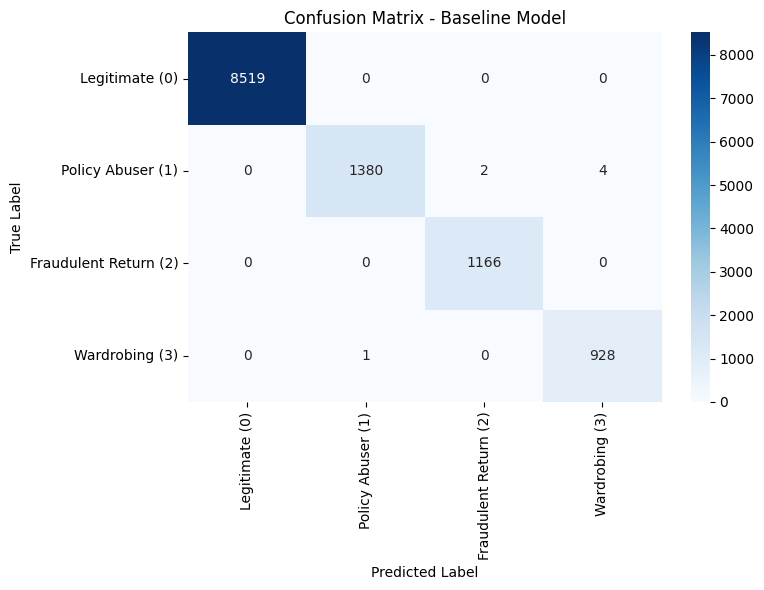

In [10]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

# 5. Feature importance

In [11]:
importance = baseline_pipeline.named_steps['classifier'].feature_importances_
feature_names = categorical_cols + numerical_cols

In [12]:
# sort features by importance
indices = np.argsort(importance)[::-1]

/tmp/ipykernel_16/3924012517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance[indices][:15], y=[feature_names[i] for i in indices][:15], palette='viridis')


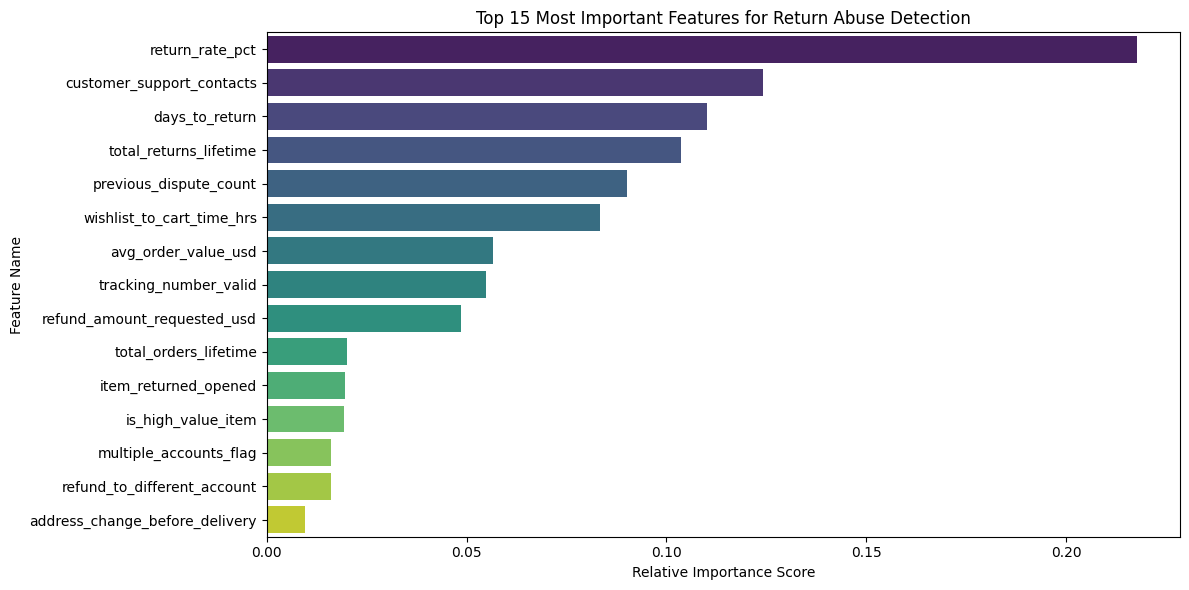

In [13]:
# visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=importance[indices][:15], y=[feature_names[i] for i in indices][:15], palette='viridis')
plt.title('Top 15 Most Important Features for Return Abuse Detection')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()

### 🏁 Conclusion & Next Steps
Our baseline Random Forest classifier performs exceptionally well on this dataset, achieving near-perfect classification metrics across all classes. 

#### 📈 Key Takeaways:
- **Top Predictors:** Features like `return_rate_pct`, `customer_support_contacts`, `days_to_return`, and `total_returns_lifetime` have the strongest predictive power.
- **Data Patterns:** The near-perfect metrics indicate that behavior patterns defining return abuse are distinct and explicitly traceable using historical order/return behaviors.

#### 🚀 Future Iterations to try:
1. **LightGBM/XGBoost:** Train a gradient boosting model to see if it trains faster while maintaining accuracy.
2. **Feature Engineering:** Calculate interaction features like the ratio of `refund_amount_requested_usd` to `avg_order_value_usd`.
3. **Hyperparameter Tuning:** Use `GridSearchCV` or `RandomizedSearchCV` if working with a noisier variant of the dataset.